# Debajo de la selva amazónica había una civilización de constructores

Un avión pasó 4.430 km sobre el suroeste de la Amazonía disparando láser al suelo. El láser atravesó las copas de los árboles y devolvió el terreno desnudo. Aparecieron zanjas, terraplenes y recintos geométricos: 406 obras de tierra en una sola campaña. Tantas como las que antes se creía que existían en TODA la Amazonía.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Pärssinen et al. (2026), *Nature* · [DOI](https://doi.org/10.1038/s41586-026-10835-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-29-geoglifos-amazonia-lidar/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/HhgT95SP8h4)

## Qué midieron

En 2024, el equipo voló un LiDAR aerotransportado (ALS) sobre los estados de Acre y Amazonas, en Brasil. El LiDAR envía pulsos de láser y mide el tiempo de rebote; una parte de esos pulsos se cuela entre las hojas y llega al suelo, así que permite "quitar" el bosque y ver el relieve por debajo.

Con esa técnica documentaron 432 obras de tierra (*earthworks*): zanjas, terraplenes y recintos geométricos hechos por poblaciones precoloniales. De esas, 36 ya se conocían — las otras 396 son nuevas. El catálogo público que vamos a abrir tiene 406 (26 quedan reservadas por estar en territorios indígenas).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_CATALOGO        = 406      # geoglifos en el catálogo público (Suppl. Table 2)
N_DOCUMENTADOS    = 432      # total documentados en el vuelo LiDAR
N_YA_CONOCIDOS    = 36       # ya conocidos antes del vuelo
VUELO_KM          = 4430     # km de vuelo ALS (2024)
FUENTE = 'Fuente: Parssinen et al. (2026), Nature | Datos: Supplementary Table 2'
COLOR_DATOS       = '#2563EB'   # azul CaM
COLOR_ALERTA      = '#DC2626'   # rojo
COLOR_REFERENCIA  = '#D97706'   # amber
COLOR_SECUNDARIO  = '#059669'   # emerald

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def es_num(x, dec=2):
    """Formato espanol: coma decimal para el texto que ve el lector."""
    return f'{x:.{dec}f}'.replace('.', ',')

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga del catalogo
df = pd.read_csv('datos/geoglifos_amazonia.csv')
df['aquiry'] = df['meets_aquiry_def'].map({'y': 'Cumple Aquiry', 'n': 'No cumple'})

print(f"Catálogo: {len(df)} geoglifos")
print(f"Tamaño (ha): mediana {es_num(df['size_ha'].median())} | "
      f"media {es_num(df['size_ha'].mean())} | rango {es_num(df['size_ha'].min())}-{es_num(df['size_ha'].max())}")
print(f"Superficie total intervenida: {df['size_ha'].sum():.0f} ha")
print(f"Cumplen la definición Aquiry: {(df['meets_aquiry_def']=='y').sum()} | "
      f"no: {(df['meets_aquiry_def']=='n').sum()}")
print(f"Extensión geográfica: {es_num(df['lat_deg_s'].max()-df['lat_deg_s'].min())} de latitud x "
      f"{es_num(df['lon_deg_w'].max()-df['lon_deg_w'].min())} de longitud")

Catálogo: 406 geoglifos
Tamaño (ha): mediana 2,12 | media 2,93 | rango 0,16-15,59
Superficie total intervenida: 1190 ha
Cumplen la definición Aquiry: 284 | no: 122
Extensión geográfica: 5,31 de latitud x 4,63 de longitud


## Dónde están

Cada punto es una obra de tierra que el láser encontró bajo el bosque.

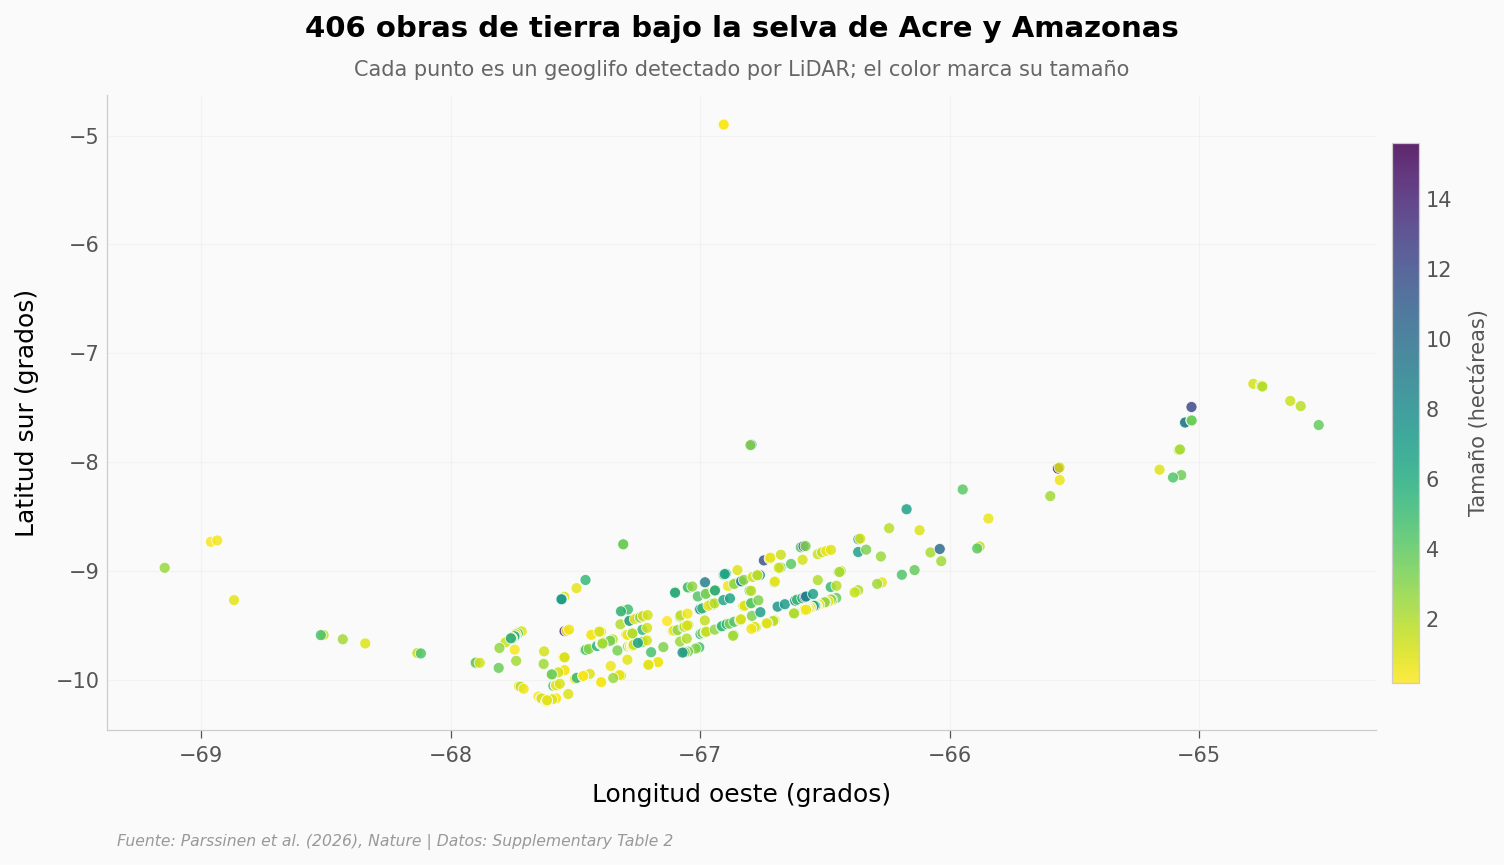

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

sc = ax.scatter(df['lon_deg_w'], df['lat_deg_s'],
                c=df['size_ha'], cmap='viridis_r',
                s=28, alpha=0.85, edgecolors='white', linewidths=0.4, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.01)
cbar.set_label('Tamaño (hectáreas)', fontsize=10, color='#555555')

ax.set_title('406 obras de tierra bajo la selva de Acre y Amazonas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un geoglifo detectado por LiDAR; el color marca su tamaño',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud oeste (grados)')
ax.set_ylabel('Latitud sur (grados)')
ax.grid(True, alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_geoglifos.png', dpi=200, bbox_inches='tight')
plt.show()

No es una obra aislada: los geoglifos se reparten a lo largo de más de 5 grados de latitud (unos 590 km de norte a sur) y 4,6 de longitud. Se concentran en franjas, no salpicados al azar — el patrón que deja gente que eligió dónde vivir, no la geología. Y los más grandes (los tonos oscuros) no están amontonados en un solo punto: aparecen dispersos por toda la región.

## ¿De qué tamaño hablamos?

Un geoglifo puede ser una zanja pequeña o un recinto enorme. Veamos cómo se reparten los 406 por tamaño.

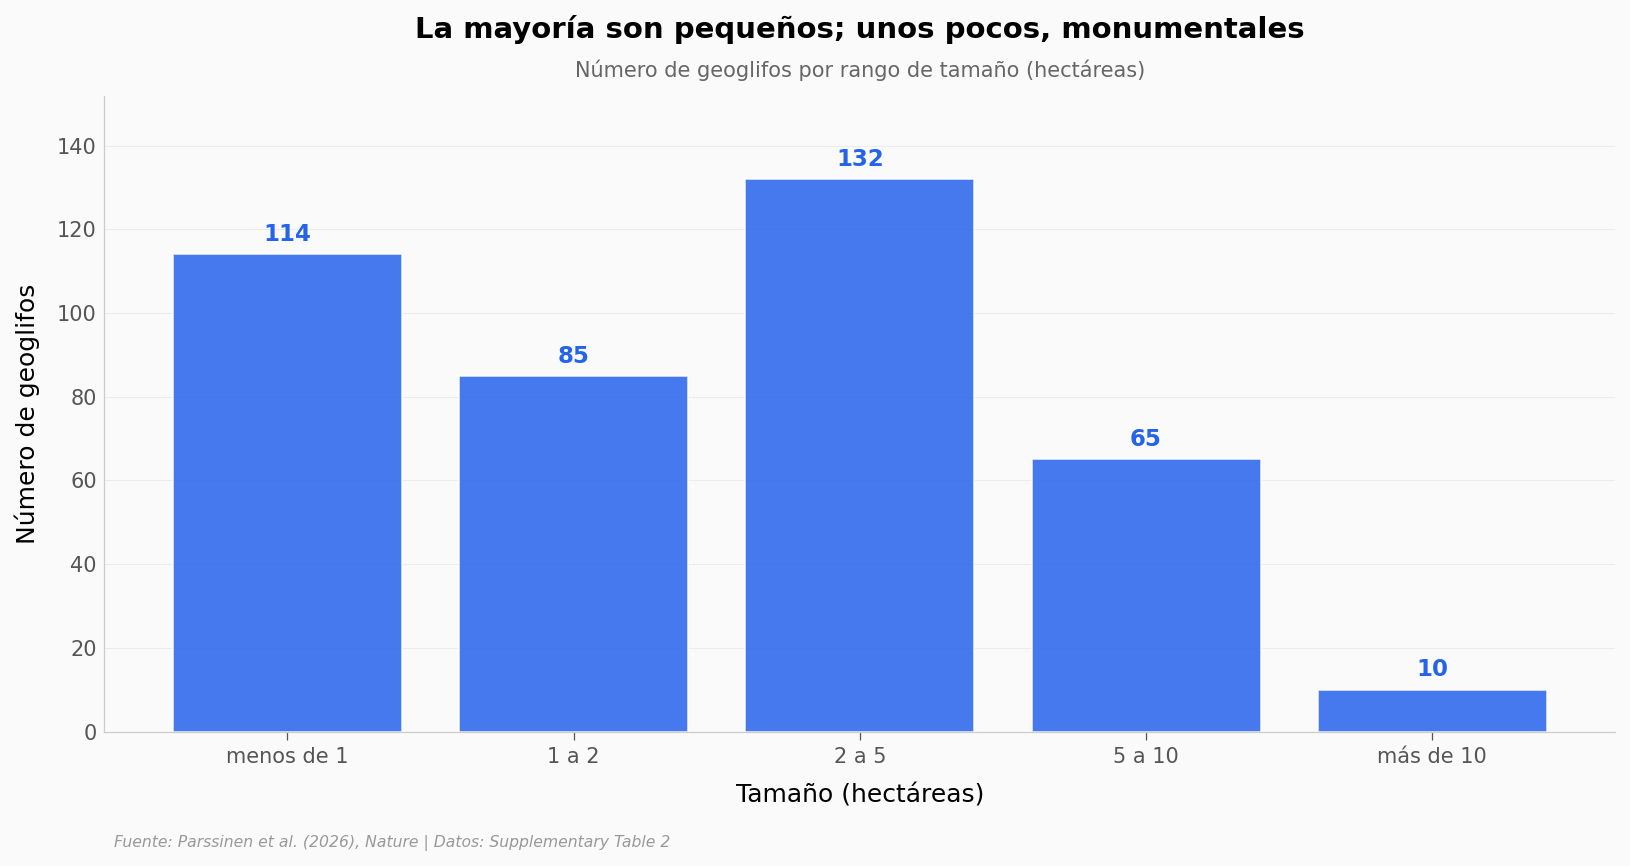

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

bins = [0, 1, 2, 5, 10, 100]
labels = ['menos de 1', '1 a 2', '2 a 5', '5 a 10', 'más de 10']
buckets = pd.cut(df['size_ha'], bins=bins, labels=labels, right=False)
counts = buckets.value_counts().reindex(labels)

bars = ax.bar(range(len(labels)), counts.values,
              color=COLOR_DATOS, alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(int(v)), ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_DATOS)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylim(0, counts.max() * 1.15)
ax.set_title('La mayoría son pequeños; unos pocos, monumentales',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Número de geoglifos por rango de tamaño (hectáreas)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tamaño (hectáreas)')
ax.set_ylabel('Número de geoglifos')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tamanos_buckets.png', dpi=200, bbox_inches='tight')
plt.show()

## Una pista sobre para qué servían

El equipo marca cuáles obras cumplen la "definición Aquiry" (*Aquiry*): un tipo concreto de recinto geométrico asociado a esta tradición. 284 la cumplen; 122 no. ¿Son más grandes los que la cumplen?

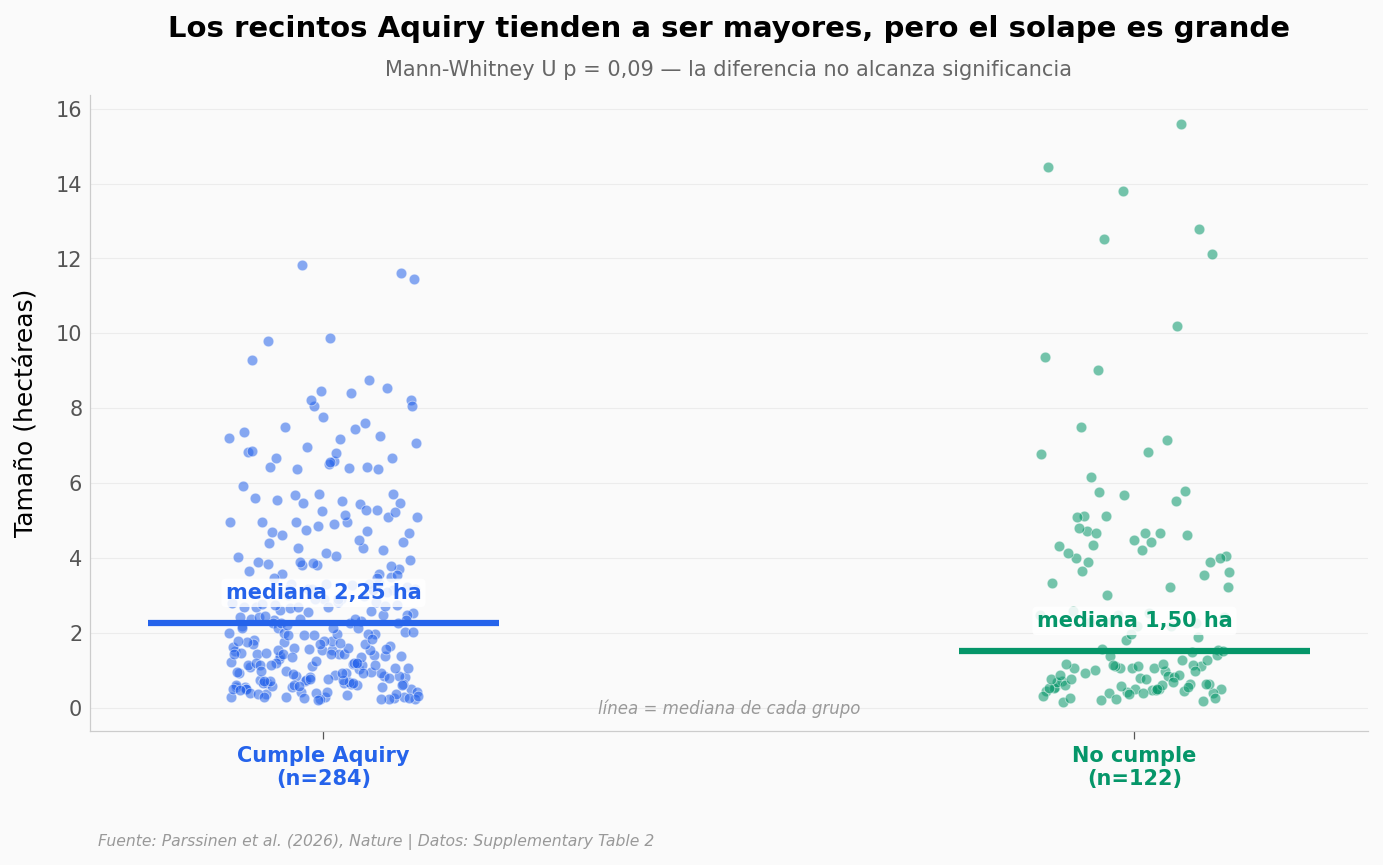

Mediana Aquiry: 2,25 ha (n=284) | No cumple: 1,50 ha (n=122)
Mann-Whitney U=19140, p=0,094


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
np.random.seed(42)

grupos = [
    ('Cumple Aquiry', df[df['meets_aquiry_def'] == 'y']['size_ha'].values, COLOR_DATOS),
    ('No cumple',     df[df['meets_aquiry_def'] == 'n']['size_ha'].values, COLOR_SECUNDARIO),
]
positions = [0, 1.2]

for pos, (nombre, vals, color) in zip(positions, grupos):
    n = len(vals)
    x = np.linspace(pos - 0.14, pos + 0.14, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=color, s=26, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=5)
    med = np.median(vals)
    ax.hlines(med, pos - 0.26, pos + 0.26, color=color, linewidth=3, zorder=6)
    ax.text(pos, med + 0.55, f'mediana {es_num(med)} ha',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85),
            zorder=7)

# Mann-Whitney (datos sesgados -> no parametrico)
a = df[df['meets_aquiry_def'] == 'y']['size_ha']
b = df[df['meets_aquiry_def'] == 'n']['size_ha']
u, p = stats.mannwhitneyu(a, b, alternative='two-sided')

ax.set_xticks(positions)
ax.set_xticklabels([f'{g[0]}\n(n={len(g[1])})' for g in grupos], fontsize=10, fontweight='bold')
for tick, g in zip(ax.get_xticklabels(), grupos):
    tick.set_color(g[2])
ax.set_ylabel('Tamaño (hectáreas)')
ax.set_title('Los recintos Aquiry tienden a ser mayores, pero el solape es grande',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Mann-Whitney U p = {es_num(p)} — la diferencia no alcanza significancia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.5, 0.02, 'línea = mediana de cada grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='center', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_aquiry.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mediana Aquiry: {es_num(a.median())} ha (n={len(a)}) | No cumple: {es_num(b.median())} ha (n={len(b)})")
print(f"Mann-Whitney U={u:.0f}, p={es_num(p, 3)}")

## ¿Qué tan lejos llega esto?

Volvamos al tamaño de los geoglifos, pero mirando la forma completa de la distribución.

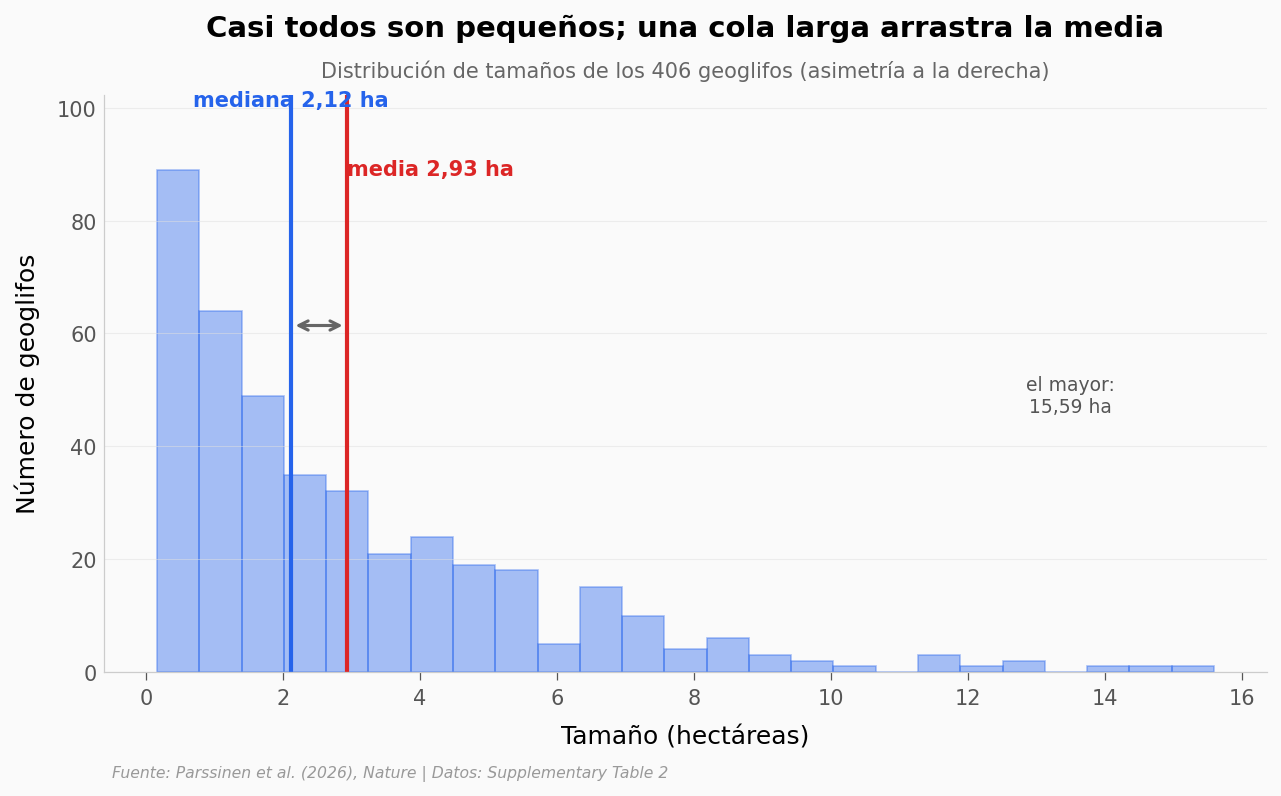

Asimetría (skew): 1,62 — cola a la derecha
Mediana 2,12 ha < Media 2,93 ha: la cola de geoglifos grandes sube el promedio


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = df['size_ha'].values
med = np.median(data)
mean = np.mean(data)

n, bins, patches = ax.hist(data, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=med, color=COLOR_DATOS, linewidth=2.0)
ax.axvline(x=mean, color=COLOR_ALERTA, linewidth=2.0)
ax.annotate('', xy=(mean, y_max * 0.6), xytext=(med, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(med, y_max * 0.98, f'mediana {es_num(med)} ha', color=COLOR_DATOS,
        ha='center', fontsize=10, fontweight='bold')
ax.text(mean, y_max * 0.86, f'media {es_num(mean)} ha', color=COLOR_ALERTA,
        ha='left', fontsize=10, fontweight='bold')
ax.text(13.5, y_max * 0.45, f'el mayor:\n{es_num(data.max())} ha', color='#555555',
        ha='center', fontsize=9)

ax.set_title('Casi todos son pequeños; una cola larga arrastra la media',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de tamaños de los 406 geoglifos (asimetría a la derecha)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tamaño (hectáreas)')
ax.set_ylabel('Número de geoglifos')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_tamanos.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Asimetría (skew): {es_num(stats.skew(data))} — cola a la derecha")
print(f"Mediana {es_num(med)} ha < Media {es_num(mean)} ha: la cola de geoglifos grandes sube el promedio")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El catálogo público tiene 406 geoglifos | ✅ | 406 filas en Supplementary Table 2, con coordenadas y tamaño |
| 432 documentados, 396 nuevos (36 ya conocidos) | ✅ | Cifras del paper; el catálogo público excluye 26 en territorios indígenas |
| Tamaño mediano 2,12 ha (rango 0,16–15,59 ha) | ✅ | Calculado sobre las 406 filas; distribución asimétrica a la derecha (skew 1,62) |
| Los recintos Aquiry son mayores | ⚠️ | Medianas 2,25 vs 1,50 ha, pero Mann-Whitney p = 0,09 — no alcanza significancia |
| >20.000 geoglifos en la región (tanto como toda la Amazonía) | ⚠️ | Extrapolación del paper a partir de la densidad observada, no un conteo directo |
| 1,25–3 millones de personas en el año 100–300 d.C. | ⚠️ | **Propuesta**, no medición: asume ~300 personas por geoglifo para construirlo y mantenerlo |

> **Limitaciones:** el catálogo cubre lo que interceptó el corredor de vuelo (4.430 km), no toda la región — 13 geoglifos quedan parcialmente fuera del barrido. Las cifras de población son un modelo con un supuesto explícito, no un censo. La extrapolación a >20.000 depende de que la densidad observada valga para áreas no sobrevoladas.

## Ahora tú

Los datos están cargados en `df`. Tres preguntas para explorar:

1. **¿Cambia el mapa si separas por calidad de contorno?** La columna `outline_clarity` marca `g` (contorno claro) y `s` (algo claro). Colorea el mapa por esa columna en vez de por tamaño — `c=df['outline_clarity'].map({'g':0,'s':1})`.
2. **¿Dónde están los gigantes?** Filtra los geoglifos de más de 10 ha (`df[df['size_ha'] > 10]`) y mira sus coordenadas. ¿Se agrupan o están dispersos?
3. **¿Cuánta superficie suman?** Ya sabes que son 1.190 ha en total. ¿Qué fracción aportan el 10% más grande? Ordena por `size_ha` y suma la cola.

In [6]:
# --- EXPERIMENTA AQUI ---
# Cuanta superficie concentra el 10% de geoglifos mas grandes?
ordenados = df.sort_values('size_ha', ascending=False)
top10pct = ordenados.head(int(len(df) * 0.10))

total = df['size_ha'].sum()
aporte = top10pct['size_ha'].sum()

print(f"El 10% más grande ({len(top10pct)} geoglifos) suma {aporte:.0f} ha")
print(f"de un total de {total:.0f} ha -> {aporte/total*100:.0f}% de la superficie")
print(f"Tamaño de corte (percentil 90): {es_num(df['size_ha'].quantile(0.90))} ha")

El 10% más grande (40 geoglifos) suma 362 ha
de un total de 1190 ha -> 30% de la superficie
Tamaño de corte (percentil 90): 6,67 ha


## Fuentes

**Paper**: [Over 20,000 precolonial earthworks in the Southwest Amazonia](https://doi.org/10.1038/s41586-026-10835-7)  
*Nature, 2026-07-29*

**Datos**: [Supplementary Table 2 — catálogo de 406 geoglifos](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10835-7/MediaObjects/41586_2026_10835_MOESM1_ESM.docx)  
*Nature (Supplementary Information), 2026-07-29*

*16 afirmaciones del notebook verificadas contra estas fuentes*